In [1]:
import numpy as np
from bstrapping.weights.gaussian_weights import GaussianWeights

from bstrapping.bootstrap_procedures.weighted_bootstrap import WeightedBootstrap
from bstrapping.synthetic_time_series.moving_average import MovingAverage
from bstrapping.weights.auto_regressive_weights import AutoRegressiveWeights
from bstrapping.weights.moving_average import MovingAverageWeights
import pandas as pd
import matplotlib.pyplot as plt

from typing import List

In [2]:
pd.set_option('display.max_columns', None)

# Testing different bootstrap procedures for a single sample

In [3]:
# specify variance, mean and number of the samples
mean = 4
number_sample_points = 2000

# generate samples from a normal distribution
time_series = MovingAverage(mean=mean, parameters=np.array([0.8, 0.6]))
samples = time_series.generate_samples(number_samples=number_sample_points)
print(f"Estimated mean: {np.mean(samples)}")

Estimated mean: 4.042113293189462


In [4]:
# Benchmark
evaluation_bootstraps = []
for weights in [AutoRegressiveWeights(samples=samples),
                GaussianWeights(samples=samples),
                MovingAverageWeights(samples=samples)]:
    bootstrap = WeightedBootstrap(samples=samples, weights=weights, number_bootstrap_samples=100)
    # asymptotic variance and confidence interval
    evaluation_bootstraps.append([number_sample_points * bootstrap.bootstrapped_variance,
                                  bootstrap.bootstrapped_confidence_interval(alpha=0.05)])

evaluation_bootstraps = dict(zip(['AR', 'Multiplier', 'MA'], evaluation_bootstraps))

2000 samples with dimension 1 were obtained. 

Bootstrapping...


100%|██████████| 100/100 [00:00<00:00, 145.85it/s]


2000 samples with dimension 1 were obtained. 

Bootstrapping...


100%|██████████| 100/100 [00:00<00:00, 12977.02it/s]


2000 samples with dimension 1 were obtained. 

Bootstrapping...


100%|██████████| 100/100 [00:08<00:00, 11.62it/s]


In [5]:
print(
    f"True asymptotic variance: {time_series.asymptotic_variance}\nEstimated mean from samples: {np.mean(samples)}\nTrue mean: {mean}")

True asymptotic variance: 5.76
Estimated mean from samples: 4.042113293189462
True mean: 4


In [6]:
pd.DataFrame(evaluation_bootstraps)

,AR,Multiplier,MA
0,5.265586,1.815578,4.812634
1,"[3.933799001015994, 4.121475840160034]","[3.97755196978651, 4.0995333891965675]","[3.9562889848653833, 4.1325869362952625]"


# Statistical evaluation of the bootstrap procedures for fixed sample size

In [7]:
runs = 10

In [8]:
%%capture
# Benchmark
bootstrapped_variances = [[], [], []]
for _ in range(runs):
    samples = time_series.generate_samples(number_samples=number_sample_points)
    for i, weights in enumerate([AutoRegressiveWeights(samples=samples),
                                 GaussianWeights(samples=samples),
                                 #MovingAverageWeights(samples=samples)
                                 ]):
        bootstrap = WeightedBootstrap(samples=samples, weights=weights, number_bootstrap_samples=100)
        # asymptotic variance and confidence interval
        bootstrapped_variances[i].append(number_sample_points * bootstrap.bootstrapped_variance,
                                         )

statistical_evaluation = [[np.mean(variance), np.std(variance)] for variance in bootstrapped_variances]
statistical_evaluation = dict(zip(['AR',
                                   'Multiplier',
                                   #'MA'
                                   ], statistical_evaluation))

In [9]:
print(f"Estimated mean: {np.mean(samples)}")

Estimated mean: 4.020521089889553


In [10]:
pd.DataFrame(statistical_evaluation, index=['mean', 'std'])

,AR,Multiplier
mean,5.532747,1.968078
std,1.070082,0.269238


# Statistical evaluation of the bootstrap procedures for increasing sample size

In [11]:
def evaluate_bootstraps(sample_size: int, runs: int = 100, time_series: MovingAverage = time_series,
                        alpha: float = 0.05):
    bootstrapped_variances = [[], [], []]
    mean_in_confidence_interval = [[], [], []]
    for _ in range(runs):
        samples = time_series.generate_samples(number_samples=sample_size)
        for i, weights in enumerate([AutoRegressiveWeights(samples=samples),
                                     GaussianWeights(samples=samples),
                                     #MovingAverageWeights(samples=samples)
                                     ]):
            bootstrap = WeightedBootstrap(samples=samples, weights=weights, number_bootstrap_samples=100)
            # asymptotic variance and confidence interval
            bootstrapped_variances[i].append(sample_size * bootstrap.bootstrapped_variance,
                                             )
            mean_in_confidence_interval[i].append(bootstrap.bootstrapped_confidence_interval(alpha=alpha)[0] < mean <
                                                  bootstrap.bootstrapped_confidence_interval(alpha=alpha)[1])
    return bootstrapped_variances, mean_in_confidence_interval

In [12]:
def benchmark_bootstraps(sample_sizes: List[int], runs: int = 100):
    benchmark_var = []
    benchmark_conf = []
    for sample_size in sample_sizes:
        bootstrapped_variance, mean_in_confidence_interval = evaluate_bootstraps(sample_size=sample_size, runs=runs)
        benchmark_var.append(bootstrapped_variance)
        benchmark_conf.append(mean_in_confidence_interval)

    return benchmark_var, benchmark_conf


In [13]:
%%capture
runs = 100
sample_sizes = [1000, 5000, 9000]
alpha = 0.05
# of the form 0 index: sample sizes 1 index: bootstrap procedures 2 index: bootstrapped variances
plain_result, in_confidence_interval = benchmark_bootstraps(sample_sizes=sample_sizes, runs=runs)

In [14]:
list_name_weights = ['AR',
                     'Multiplier',
                     #'MA',
                     ]
statistical_evaluation = {("mean", "Asymptotic variance"): [time_series.asymptotic_variance for
                                                            sample_size_index in range(len(plain_result))]
                          } | {
                             ("mean", name,): [np.mean(plain_result[sample_size_index][name_index]) for
                                               sample_size_index in range(len(plain_result))]

                             for name_index, name in enumerate(list_name_weights)
                         } | {
                             ("std", name,): [np.std(plain_result[sample_size_index][name_index]) for
                                              sample_size_index in range(len(plain_result))]
                             for name_index, name in enumerate(list_name_weights)
                         } | {("In confidence interval", name): [
    np.sum(in_confidence_interval[sample_size_index][name_index]) / runs for
    sample_size_index in range(len(plain_result))]
                             for name_index, name in enumerate(list_name_weights)
                         } | {
                             ("In confidence interval", "Confidence level"): [
                                 (1 - alpha) for
                                 sample_size_index in range(len(plain_result))]
                             for name_index, name in enumerate(list_name_weights)}

statistical_evaluation = pd.DataFrame(statistical_evaluation, index=sample_sizes)

In [15]:
statistical_evaluation

mean                            std             \
     Asymptotic variance        AR Multiplier        AR Multiplier   
1000                5.76  5.422227   1.993484  1.185562   0.334477   
5000                5.76  5.513667   2.012471  1.105497   0.285567   
9000                5.76  5.489188   1.988387  0.904231   0.258451   

     In confidence interval                              
                         AR Multiplier Confidence level  
1000                   0.97       0.78             0.95  
5000                   0.95       0.76             0.95  
9000                   0.92       0.74             0.95

<Axes: xlabel='Sample size', ylabel='Bootstrapped variance'>

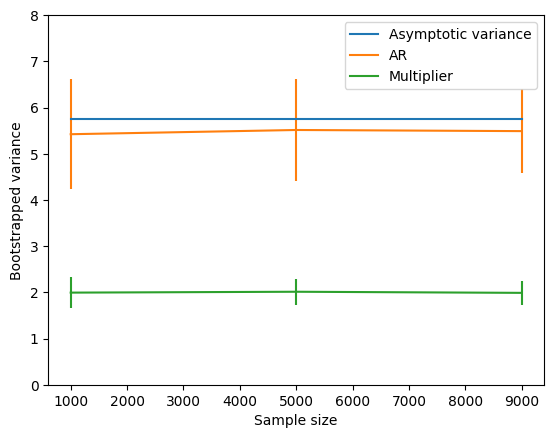

In [26]:
statistical_evaluation["mean"].plot(yerr=statistical_evaluation["std"],
                                    xlabel="Sample size",
                                    ylabel="Bootstrapped variance",
                                    ylim=[0, 8])

<Axes: xlabel='Stochastic process', ylabel='Coverage probability'>

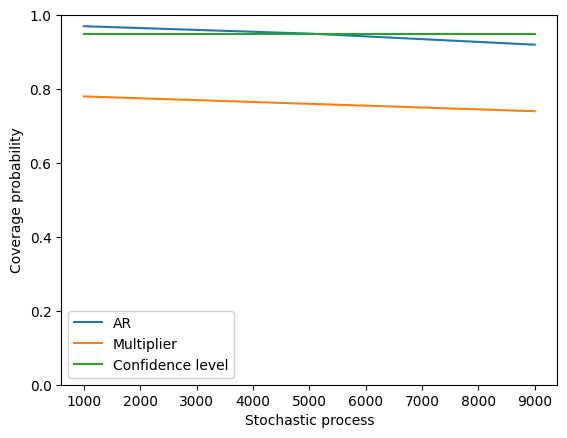

In [17]:
statistical_evaluation["In confidence interval"].plot(ylabel="Coverage probability",
                                                      xlabel="Stochastic process", ylim=[0, 1])

# Statistical evaluation of the bootstrap procedures for increasing dependencies

In [237]:
dependence_coefficients = [
    np.array([0]),
    np.array([0.8]),
    np.array([0.8**i for i in range(10)]),
]

name_dependence_coefficients = [
    "iid",
    "MA(1)",
    "MA(10)",
]

In [19]:
def evaluate_bootstrap_increasing_dependencies(dependence_coefficients: List[np.ndarray],
                                               sample_size: int = 100,
                                               runs: int = 100):
    true_asymptotic_variances = []
    variance = []
    benchmark_var = []
    benchmark_conf = []
    for dependence_coefficient in dependence_coefficients:
        time_series_current = MovingAverage(mean=mean, parameters=dependence_coefficient)
        true_asymptotic_variances.append(time_series_current.asymptotic_variance)
        variance.append(time_series_current.variance)
        bootstrapped_variance, mean_in_confidence_interval = evaluate_bootstraps(sample_size=sample_size, runs=runs,
                                                                                 time_series=time_series_current)
        benchmark_var.append(bootstrapped_variance)
        benchmark_conf.append(mean_in_confidence_interval)

    return benchmark_var, benchmark_conf, true_asymptotic_variances, variance

In [20]:
%%capture
plain_result_increasing_dependencies, in_confidence_interval, true_asymptotic_variances, variance = evaluate_bootstrap_increasing_dependencies(
    sample_size=5000,
    dependence_coefficients=dependence_coefficients,
    runs=runs)

In [21]:
statistical_evaluation_dependencies = {("mean", "Variance"): variance} | {
    ("mean", "Asymptotic variance"): true_asymptotic_variances} | {
                                          ("mean", name,): [
                                              np.mean(
                                                  plain_result_increasing_dependencies[sample_size_index][name_index])
                                              for
                                              sample_size_index in range(len(plain_result_increasing_dependencies))]

                                          for name_index, name in enumerate(list_name_weights)
                                      } | {
                                          ("std", name,): [np.std(
                                              plain_result_increasing_dependencies[sample_size_index][name_index])
                                              for
                                              sample_size_index in
                                              range(len(plain_result_increasing_dependencies))]
                                          for name_index, name in enumerate(list_name_weights)
                                      } | {("In confidence interval", name): [
    np.sum(in_confidence_interval[sample_size_index][name_index]) / runs for
    sample_size_index in range(len(plain_result_increasing_dependencies))]
                                          for name_index, name in enumerate(list_name_weights)
                                      } | {
                                          ("In confidence interval", "Confidence level"): [
                                              (1 - alpha) for
                                              sample_size_index in range(len(plain_result_increasing_dependencies))]
                                          for name_index, name in enumerate(list_name_weights)}

statistical_evaluation_dependencies = pd.DataFrame(statistical_evaluation_dependencies,
                                                   index=name_dependence_coefficients)

In [22]:
statistical_evaluation_dependencies

mean                                                std             \
      Variance Asymptotic variance        AR Multiplier        AR Multiplier   
iid       1.00                1.00  0.992135   1.004090  0.146386   0.150984   
MA(1)     1.64                3.24  3.138676   1.595865  0.508025   0.217485   
MA(2)     2.00                5.76  5.440795   1.965476  0.881780   0.304165   
MA(3)     2.16                7.84  7.469316   2.148610  1.307169   0.311623   

      In confidence interval                              
                          AR Multiplier Confidence level  
iid                     0.88       0.87             0.95  
MA(1)                   0.96       0.82             0.95  
MA(2)                   0.97       0.79             0.95  
MA(3)                   0.96       0.72             0.95

<Axes: xlabel='Stochastic process', ylabel='Bootstrapped variance'>

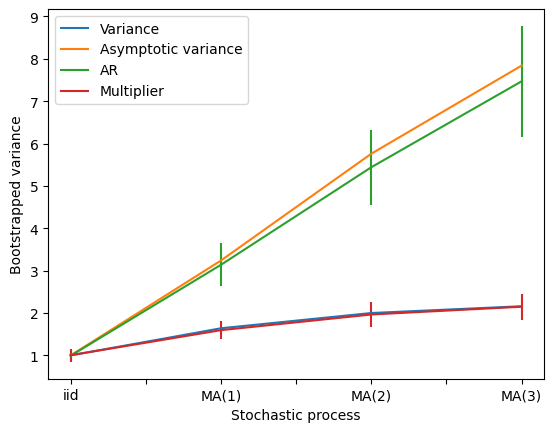

In [23]:
statistical_evaluation_dependencies["mean"].plot(yerr=statistical_evaluation_dependencies["std"],
                                                 xlabel="Stochastic process", ylabel="Bootstrapped variance")

<Axes: xlabel='Stochastic process', ylabel='Coverage probability'>

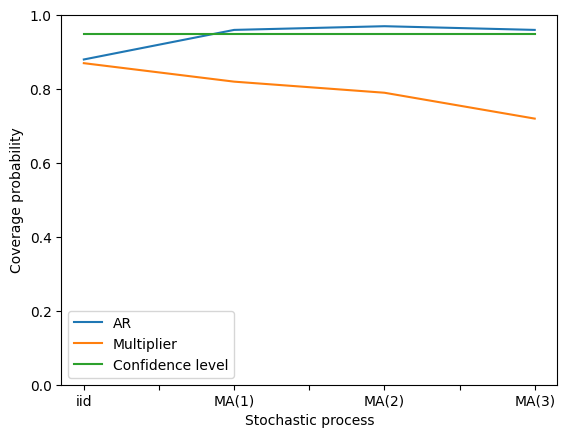

In [24]:
statistical_evaluation_dependencies["In confidence interval"].plot(ylabel="Coverage probability",
                                                                   xlabel="Stochastic process", ylim=[0, 1])

# Statistical evaluation of the bootstrap procedures for increasing sample size and dependencies

In [218]:
%%capture

def full_benchmark(sample_sizes: List[int], dependence_coefficients: List[np.ndarray],
                   names_dependence_coefficients: List[str], runs: int = 100):
    benchmark = []
    for sample_size in sample_sizes:
        for index, dependence_coefficient in enumerate(dependence_coefficients):
            time_series_current = MovingAverage(mean=mean, parameters=dependence_coefficient)
            bootstrapped_variances, mean_in_confidence_interval = evaluate_bootstraps(sample_size=sample_size,
                                                                                      runs=runs,
                                                                                      time_series=time_series_current)
            bootstrapped_variances = bootstrapped_variances[:-1]  # TODO: remove this later
            mean_in_confidence_interval = mean_in_confidence_interval[:-1]  # TODO: remove this later

            benchmark.append(
                np.mean(bootstrapped_variances, axis=1).tolist()
                + np.std(bootstrapped_variances, axis=1).tolist()
                + (np.sum(mean_in_confidence_interval, axis=1) / runs).tolist()
                + [1 - alpha]
                + [time_series_current.asymptotic_variance,
                   time_series_current.variance,
                   names_dependence_coefficients[index],
                   sample_size])

    return (pd.DataFrame(benchmark, columns=pd.MultiIndex.from_tuples([("mean", name,) for name in list_name_weights] +
                                                                      [("std", name,) for name in list_name_weights] +
                                                                      [("In confidence interval", name,) for name in
                                                                       list_name_weights] +
                                                                      [("In confidence interval", "Confidence level")] +
                                                                      [("mean", "Asymptotic variance"),
                                                                       ("Variance", ""),
                                                                       ("Stochastic process", ""),
                                                                       ("Sample size", "")])).set_index(
        ["Sample size"]))


In [247]:
%%capture
benchmark = full_benchmark(sample_sizes=[2000, 5000,10000,15000],
                           dependence_coefficients=dependence_coefficients,
                           names_dependence_coefficients=name_dependence_coefficients,
                           runs=100)

In [248]:
benchmark

mean                  std            In confidence interval  \
                    AR Multiplier        AR Multiplier                     AR   
Sample size                                                                     
2000          0.981941   0.976445  0.176739   0.137288                   0.93   
2000          3.262959   1.637989  0.628359   0.241781                   0.91   
2000         22.861906   3.640148  4.410243   0.597049                   0.93   
5000          1.028537   0.985982  0.180461   0.139379                   0.98   
5000          3.273268   1.651260  0.585270   0.251701                   0.94   
5000         24.187856   3.716144  5.031958   0.552805                   0.88   
10000         0.991973   0.989928  0.181321   0.142768                   0.92   
10000         3.235290   1.633030  0.582988   0.242140                   0.92   
10000        25.418863   3.681835  4.164731   0.589048                   0.85   
15000         0.991385   0.990685  0.156879   0.139134                   0.94   
15000         3.186044   1.602260  0.514182   0.210830                   0.89   
15000        26.494968   3.749514  4.633698   0.517722                   0.91   

                                                       mean  Variance  \
            Multiplier Confidence level Asymptotic variance             
Sample size                                                             
2000              0.92             0.95            1.000000  1.000000   
2000              0.78             0.95            3.240000  1.640000   
2000              0.45             0.95           29.845779  3.745752   
5000              0.96             0.95            1.000000  1.000000   
5000              0.83             0.95            3.240000  1.640000   
5000              0.49             0.95           29.845779  3.745752   
10000             0.91             0.95            1.000000  1.000000   
10000             0.74             0.95            3.240000  1.640000   
10000             0.48             0.95           29.845779  3.745752   
15000             0.93             0.95            1.000000  1.000000   
15000             0.74             0.95            3.240000  1.640000   
15000             0.50             0.95           29.845779  3.745752   

            Stochastic process  
                                
Sample size                     
2000                       iid  
2000                     MA(1)  
2000                    MA(10)  
5000                       iid  
5000                     MA(1)  
5000                    MA(10)  
10000                      iid  
10000                    MA(1)  
10000                   MA(10)  
15000                      iid  
15000                    MA(1)  
15000                   MA(10)

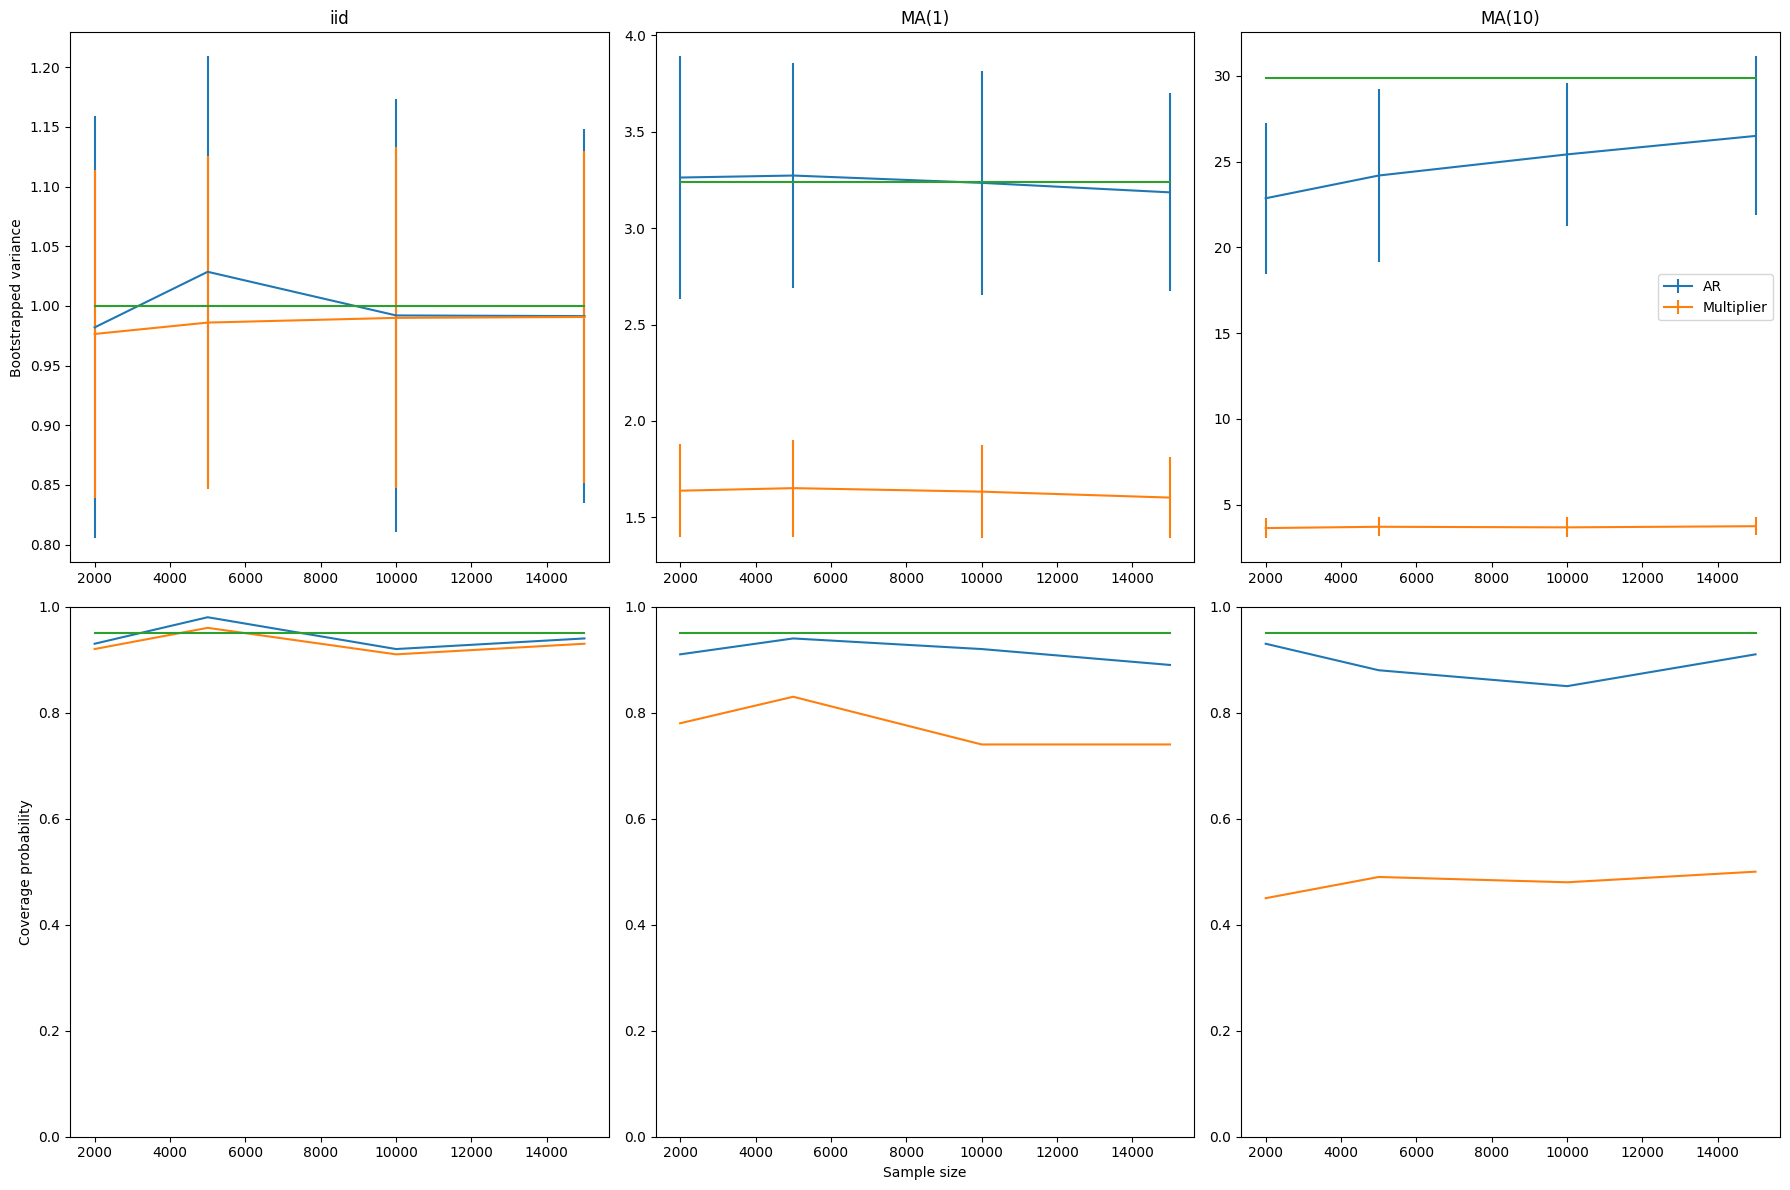

In [249]:
fig, a = plt.subplots(2, len(name_dependence_coefficients), figsize=(18, 12))

for index, name_dependence_coefficient in enumerate(name_dependence_coefficients):
    benchmark_wrt_dependence_coefficients = benchmark[benchmark["Stochastic process"] == name_dependence_coefficient]
    benchmark_wrt_dependence_coefficients["mean"].plot(yerr=benchmark_wrt_dependence_coefficients["std"],
                                                       xlabel="",
                                                       sharex=False,
                                                       legend=False,
                                                       #ylabel="Bootstrapped variance",
                                                       ax=a[0][index])
    benchmark_wrt_dependence_coefficients["In confidence interval"].plot(xlabel="", 
                                                                         #ylabel="Coverage probability", 
                                                                         legend=False,
                                                                         ax=a[1][index], 
                                                                         ylim=[0, 1])

    a[0][index].set_title(name_dependence_coefficient)
    
a[0][0].set_ylabel("Bootstrapped variance")
a[1][int(len(name_dependence_coefficients)/2)].set_xlabel("Sample size")
a[1][0].set_ylabel("Coverage probability")
a[0][-1].legend(list_name_weights)

plt.tight_layout()